In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
gpp.set_aesthetics(context = 'paper')
from scipy.stats import fisher_exact

In [2]:
#read in cleaned labeled hCRISPRiv2 nonessentials
noness_labeled = pd.read_csv('../../Data/externalData/hCRISPRiv2/hcrispriv2_seed_score_validation_input.csv')
noness_labeled

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,rs3ChenSeqScore,gene_avg_zscore,promiscuous,nonpromiscuous
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8,0.226611,-0.264203,False,True
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8,-0.344169,-0.264203,False,True
2,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8,0.537225,-0.264203,False,True
3,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8,0.267031,-0.264203,False,True
4,TCTAAGAGAGCTGCAGCCCA,TGGGTCTAAGAGAGCTGCAGCCCAGGGTCA,0.255273,ABCG8,1.061433,-0.264203,False,True
...,...,...,...,...,...,...,...,...
3204,CGCCTCAGTGAGCCGAGCAG,CTGGCGCCTCAGTGAGCCGAGCAGAGGGGC,0.634663,ZSWIM2,-0.088560,-0.243648,False,True
3205,CACATTGGGTATGCCAGTGG,TACGCACATTGGGTATGCCAGTGGGGGAAC,-0.520459,ZSWIM2,0.483515,-0.243648,False,True
3206,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2,0.419896,-0.243648,False,True
3207,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2,-0.434224,-0.243648,False,True


In [3]:
def count_overlapping_matches(seq,pattern):
    count = 0
    length = len(pattern)
    for i in range(len(seq)-1):
        if seq[i:(i+length)] == pattern:
            count +=1
    return count

In [4]:
n_list = ['A','T','C','G']
din_list = []
for n1 in n_list:
    for n2 in n_list:
        din_list.append(n1+n2)

In [5]:
#create separate column with seed sequence
noness_labeled.loc[:,'seed_seq'] = noness_labeled['sgRNA Sequence'].str[-12:]
#create column for every nucleotide containing number of occurrences within the seed sequence
for din in din_list:
    noness_labeled.loc[:,din] = noness_labeled.loc[:,'seed_seq'].apply(lambda seq: count_overlapping_matches(seq,din))

In [6]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')
#bin dinucleotide occurrences to aggregate counts >=3 into one category (for plotting)
bins = [0,1,2,3,np.inf]
labels = ['0','1','2','>2']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()


#only consider combinations with at least 30 guides
plot_df = plot_df[plot_df['group_size'] >= 30].copy()

#pivot df to allow to be plotted as heatmap
plot_df = plot_df.pivot(columns = ['Dinucleotide'], index = 'num_occurrence_bin',
              values = 'prop_promiscuous')
plot_df = plot_df.sort_values(by = ['>2'], axis=1, ascending=False)
plot_df

Dinucleotide,GG,GA,AG,GC,CC,TG,CT,AA,AC,AT,CA,GT,TA,TC,CG,TT
num_occurrence_bin,,,,,,,,,,,,,,,,
0,0.003639,0.004854,0.008421,0.010840,0.006820,0.010830,0.010593,0.011130,0.012962,0.014431,0.014535,0.009765,0.012776,0.010449,0.007867,0.011814
1,0.006375,0.009427,0.004438,0.008429,0.009740,0.008843,0.009531,0.010429,0.007311,0.002841,0.008304,0.009624,0.004137,0.007739,0.012791,0.003077
2,0.016949,0.014035,0.015007,0.005277,0.013761,0.005141,0.004651,0.002632,0.002681,0.000000,0.004847,0.007143,0.000000,0.011561,0.012346,0.000000
>2,0.043689,0.030769,0.028736,0.020408,0.016949,0.012821,0.009615,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, '0'), Text(0, 1.5, '1'), Text(0, 2.5, '2'), Text(0, 3.5, '>2')])

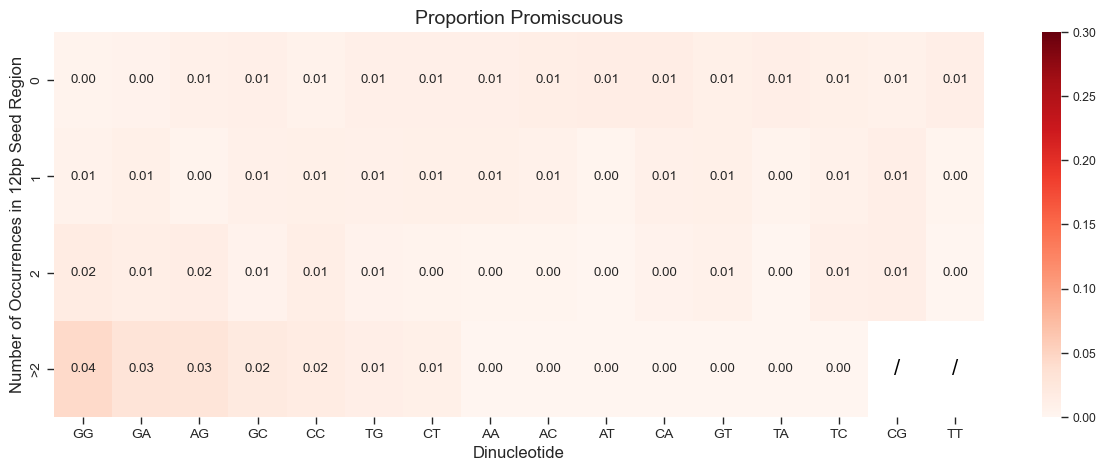

In [7]:
plt.figure(figsize=(15,5))
ax = sns.heatmap(plot_df,cmap='Reds',
               vmin=0, vmax=0.3, annot=True, fmt = '0.2f')
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        if np.isnan(plot_df.iloc[i, j]):
            ax.text(j + 0.5, i + 0.5, "/", ha='center', va='center', color='black', fontsize=16)
plt.xlabel('Dinucleotide',fontsize=12)
plt.ylabel('Number of Occurrences in 12bp Seed Region',fontsize=12)
plt.title('Proportion Promiscuous', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

In [8]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')

#if we considered all guides with >=0 counts of a certain dinucleotide, we would simply be considering every guide in the dataset
plot_df = plot_df[plot_df['num_occurrences'] > 0].copy()

#bin dinucleotide occurrences to aggregate counts >=3 into one category (for plotting)
bins = [1,2,3,4,np.inf]
labels = ['>=1','>=2','>=3','>=4']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()

#calculate number of guides / promiscuous guides with AT LEAST a certain count of each dinucleotide
plot_df['cumsum_promiscuous'] = plot_df[::-1].groupby('Dinucleotide')['sum_promiscuous'].transform('cumsum')
plot_df['cum_group_size'] = plot_df[::-1].groupby('Dinucleotide')['group_size'].transform('cumsum')

#recalculate proportion of promiscuous guides
plot_df['cumprop_promiscuous'] = plot_df['cumsum_promiscuous']/plot_df['cum_group_size']


#only consider groups with at least 30 guides for consistency with previous plot
plot_df = plot_df[plot_df['cum_group_size'] >= 30].copy()


#implement Fisher Exact test

total_promiscuous = noness_labeled['promiscuous'].sum()
total_nonpromiscuous = (~noness_labeled['promiscuous']).sum()
plot_df.loc[:,'p_value'] = plot_df.apply(lambda row: fisher_exact(np.array([[row['cumsum_promiscuous'],row['cum_group_size']-row['cumsum_promiscuous']],
                                                                  [total_promiscuous,total_nonpromiscuous]]),
                                         alternative = 'greater').pvalue, axis=1)
plot_df.loc[:,'-log(p-value)'] = -np.log10(plot_df.loc[:,'p_value'])

plot_df

,Dinucleotide,num_occurrence_bin,prop_promiscuous,sum_promiscuous,group_size,cumsum_promiscuous,cum_group_size,cumprop_promiscuous,p_value,-log(p-value)
0,AA,>=1,0.010429,9,863,10,1412,0.007082,0.825349,0.083362
1,AA,>=2,0.002632,1,380,1,549,0.001821,0.992679,0.003191
2,AA,>=3,0.000000,0,130,0,169,0.000000,1.000000,-0.000000
3,AA,>=4,0.000000,0,39,0,39,0.000000,1.000000,-0.000000
4,AC,>=1,0.007311,9,1231,10,1666,0.006002,0.921782,0.035372
5,AC,>=2,0.002681,1,373,1,435,0.002299,0.980903,0.008374
6,AC,>=3,0.000000,0,57,0,62,0.000000,1.000000,-0.000000
8,AG,>=1,0.004438,6,1352,22,2259,0.009739,0.494827,0.305546
9,AG,>=2,0.015007,11,733,16,907,0.017641,0.032041,1.494294
10,AG,>=3,0.019231,3,156,5,174,0.028736,0.031480,1.501968


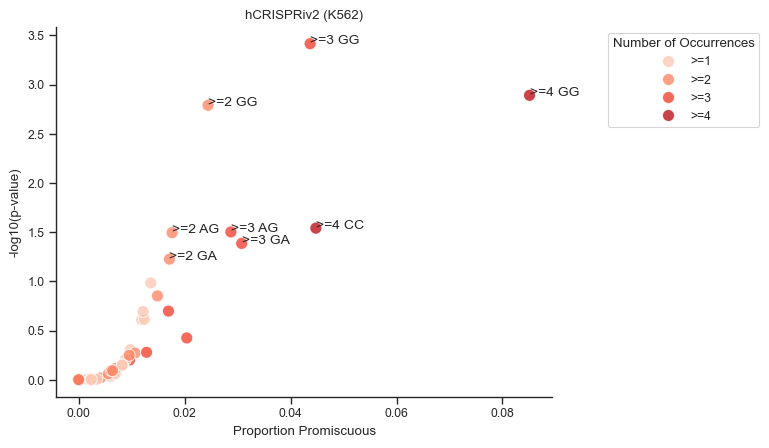

In [12]:
sns.scatterplot(data = plot_df, x = 'cumprop_promiscuous', y = '-log(p-value)', hue = 'num_occurrence_bin',
                palette='Reds', alpha = 0.8, s = 75)

texts = []
for i,row in plot_df.iterrows():
    x = row['cumprop_promiscuous']
    y = row['-log(p-value)']
    din = str(row['Dinucleotide'])
    n = str(row['num_occurrence_bin'])
    if (y > 1):
        text = plt.text(x, y, n + ' ' + din, fontsize=10)
sns.despine()

plt.xlabel('Proportion Promiscuous')
plt.ylabel('-log10(p-value)')
plt.legend(title = 'Number of Occurrences', bbox_to_anchor=(1.1,1))
plt.title('hCRISPRiv2 (K562)')

gpp.savefig("../../Figures/Figure 5/hCRISPRiv2_nonessentials_12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.pdf",dpi=300, bbox_inches = 'tight')
gpp.savefig("../../Figures/Figure 5/hCRISPRiv2_nonessentials_12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.png",dpi=300, bbox_inches = 'tight')